In [1]:
import astra
import numpy as np
import pydicom
from matplotlib import pyplot as plt
from skimage.transform import resize


def ct_scan(image):
    dx, dy = image.shape

    vol_geom = astra.create_vol_geom(dx, dy)
    proj_geom = astra.create_proj_geom('parallel', 1.0, 672,
                                       np.linspace(0, 2 * np.pi, 360, False))

    # For CPU-based algorithms, a "projector" object specifies the projection
    # model used. In this case, we use the "strip" model.
    proj_id = astra.create_projector('strip', proj_geom, vol_geom)

    # Create a sinogram from a phantom
    sinogram_id, sinogram = astra.create_sino(image, proj_id)

    astra.data2d.delete(sinogram_id)
    astra.projector.delete(proj_id)

    return sinogram


def inv_ct_scan(sinogram, image_size):

    vol_geom = astra.create_vol_geom(image_size[0], image_size[1])
    proj_geom = astra.create_proj_geom(
        'parallel', 1.0, 672, np.linspace(0, 2 * np.pi, sinogram.shape[0],
                                          False))
    sinogram_id = astra.data2d.create('-sino', proj_geom, sinogram)
    proj_id = astra.create_projector('strip', proj_geom, vol_geom)
    rec_id = astra.data2d.create('-vol', vol_geom)

    cfg = astra.astra_dict('FBP')
    cfg['ReconstructionDataId'] = rec_id
    cfg['ProjectionDataId'] = sinogram_id
    cfg['ProjectorId'] = proj_id
    # Available algorithms:
    # ART, SART, SIRT, CGLS, FBP

    # Create the algorithm object from the configuration structure
    alg_id = astra.algorithm.create(cfg)

    # Run 20 iterations of the algorithm
    # This will have a runtime in the order of 10 seconds.
    astra.algorithm.run(alg_id, 20)

    # Get the result
    image = astra.data2d.get(rec_id)

    astra.algorithm.delete(alg_id)
    astra.data2d.delete(rec_id)
    astra.data2d.delete(sinogram_id)
    astra.projector.delete(proj_id)

    return image


def add_possion_noise(hsino, alpha):

    # the output distribution ~ (mean=hsino, var=hsino/alpha)
    lsino = np.random.poisson(hsino * alpha) / alpha

    return lsino


def rescale_image(image, slope, intercept):
    return image * slope + intercept


def apply_window(image, center, width):
    image = image.copy()
    min_value = center - width // 2
    max_value = center + width // 2
    image[image < min_value] = min_value
    image[image > max_value] = max_value
    image = image / max_value
    return image


def sim_low_dose(image, dose=0.9, image_min=None, image_max=None):

    if image_min is None:
        image_min = np.min(image)

    if image_max is None:
        image_max = np.max(image)

    image = (image - image_min) / (image_max - image_min)

    sinogram = ct_scan(image)

    if dose < 1:
        nsamples = int(round(sinogram.shape[0] * dose))
        sinogram = resize(sinogram, (nsamples, sinogram.shape[1]))

    recon = inv_ct_scan(sinogram, image.shape)

    recon = recon * (image_max - image_min) + image_min

    return recon, sinogram


file_path = '1ede0d4a/7e78087264_935a0bdfbf/022_2b9552d61.dcm'
# file_path = '1ede0d4a/7e78087264_935a0bdfbf/012_5d229a46b.dcm'
# file_path = '1ede0d4a/d4cd0e7cdb_295cdf3a4f/051_fa74a61f0.dcm'

dcm = pydicom.dcmread(file_path)

window = (40, 80)
# window = (80, 200)
# window = (40, 380)

image = dcm.pixel_array
image = rescale_image(image, dcm.RescaleSlope, dcm.RescaleIntercept)
orig_brain = apply_window(image, window[0], window[1])
sinogram = ct_scan(image)

recon1, sinogram1 = sim_low_dose(image, 1)
recon1_brain = apply_window(recon1, window[0], window[1])

recon2, sinogram2 = sim_low_dose(image, 0.6)
recon2_brain = apply_window(recon2, window[0], window[1])

recon3, sinogram3 = sim_low_dose(image, 0.4)
recon3_brain = apply_window(recon3, window[0], window[1])

recon4, sinogram4 = sim_low_dose(image, 0.2)
recon4_brain = apply_window(recon4, window[0], window[1])

-1024.0 1310.0
-1125.3092 1272.4219
-1248.5452 1259.8352
-1432.0724 1196.458
-1547.4753 1044.1167


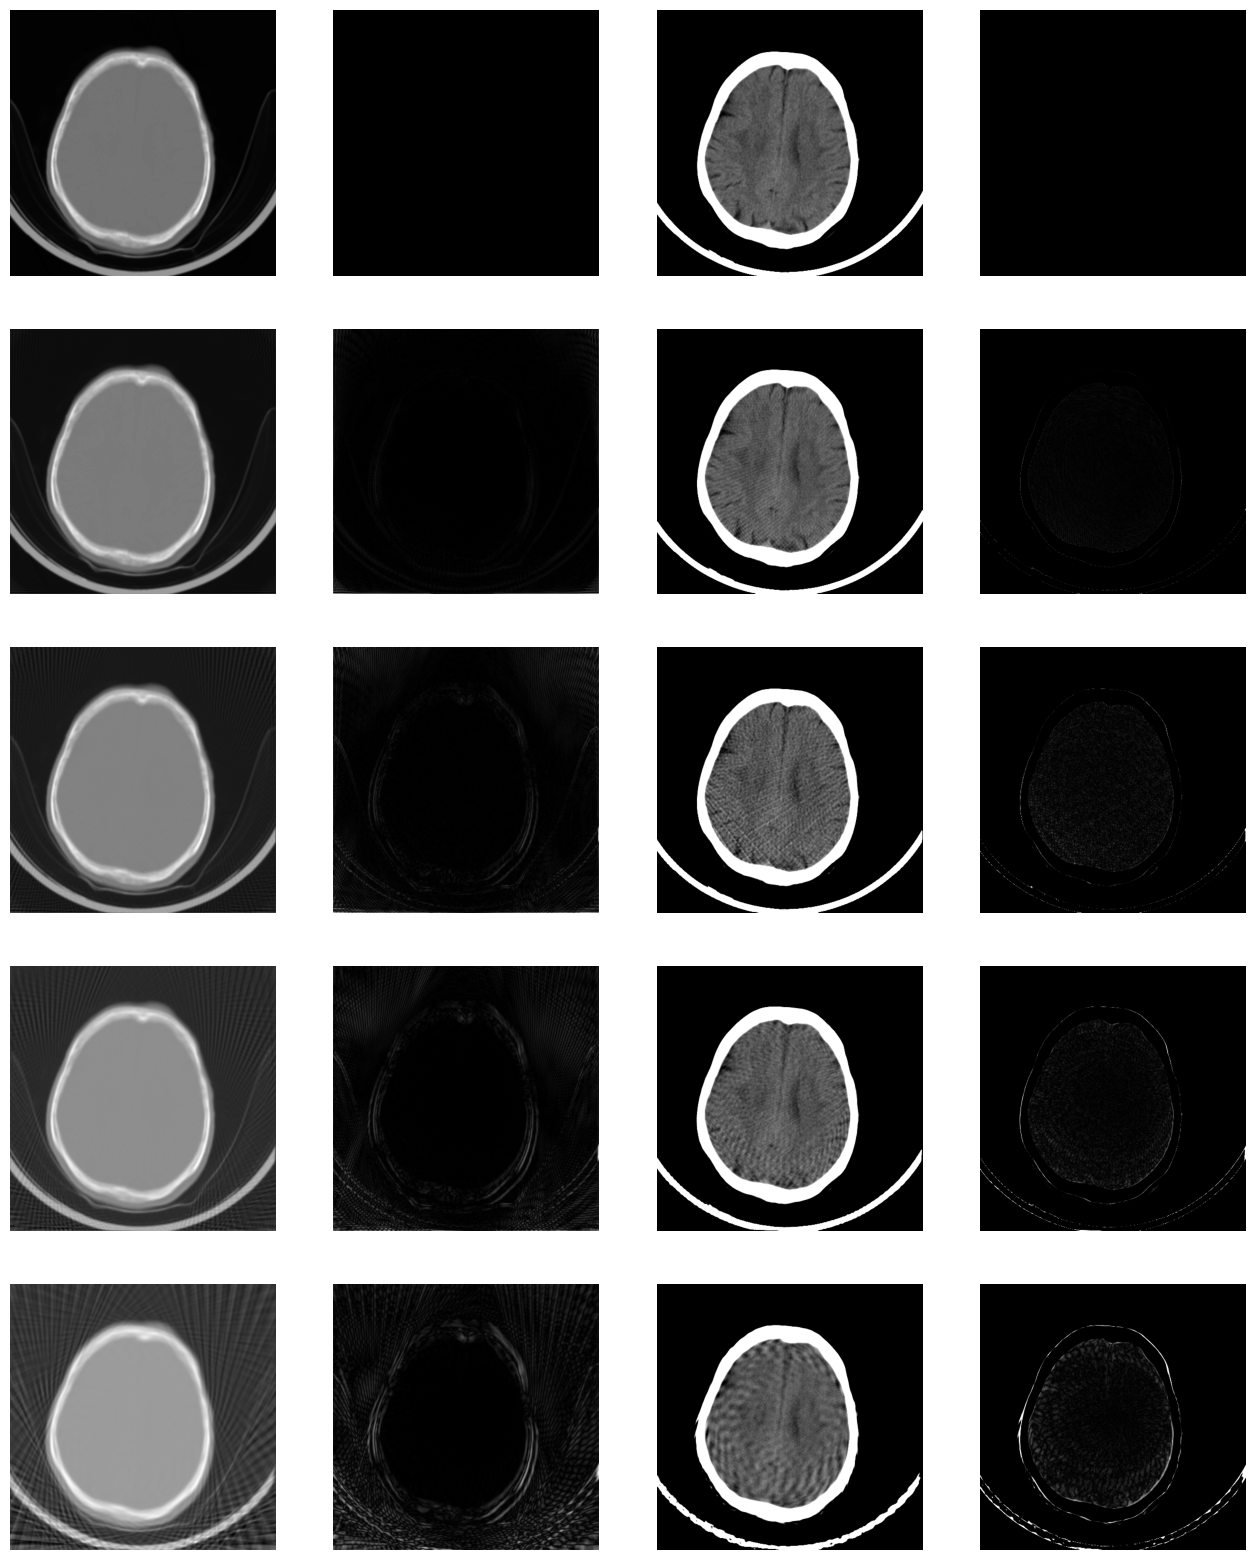

In [3]:
fig, axes = plt.subplots(nrows=5, ncols=4)
fig.set_size_inches(16, 20)
axes[0, 0].imshow(image, cmap='gray')
axes[0, 1].imshow(np.abs(image-image), cmap='gray')
axes[0, 2].imshow(orig_brain, cmap='gray')
axes[0, 3].imshow(np.abs(orig_brain - orig_brain), cmap='gray')
print(np.min(image), np.max(image))

axes[1, 0].imshow(recon1, cmap='gray')
axes[1, 1].imshow(np.abs(recon1 - image), cmap='gray')
axes[1, 2].imshow(recon1_brain, cmap='gray')
axes[1, 3].imshow(np.abs(recon1_brain - orig_brain), cmap='gray')
print(np.min(recon1), np.max(recon1))

axes[2, 0].imshow(recon2, cmap='gray')
axes[2, 1].imshow(np.abs(recon2 - image), cmap='gray')
axes[2, 2].imshow(recon2_brain, cmap='gray')
axes[2, 3].imshow(np.abs(recon2_brain - orig_brain), cmap='gray')
print(np.min(recon2), np.max(recon2))

axes[3, 0].imshow(recon3, cmap='gray')
axes[3, 1].imshow(np.abs(recon3 - image), cmap='gray')
axes[3, 2].imshow(recon3_brain, cmap='gray')
axes[3, 3].imshow(np.abs(recon3_brain - orig_brain), cmap='gray')

print(np.min(recon3), np.max(recon3))

axes[4, 0].imshow(recon4, cmap='gray')
axes[4, 1].imshow(np.abs(recon4 - image), cmap='gray')
axes[4, 2].imshow(recon4_brain, cmap='gray')
axes[4, 3].imshow(np.abs(recon4_brain - orig_brain), cmap='gray')

print(np.min(recon4), np.max(recon4))

axes = np.reshape(axes, (-1,))
for kk in range(len(axes)):
    axes[kk].set_axis_off()


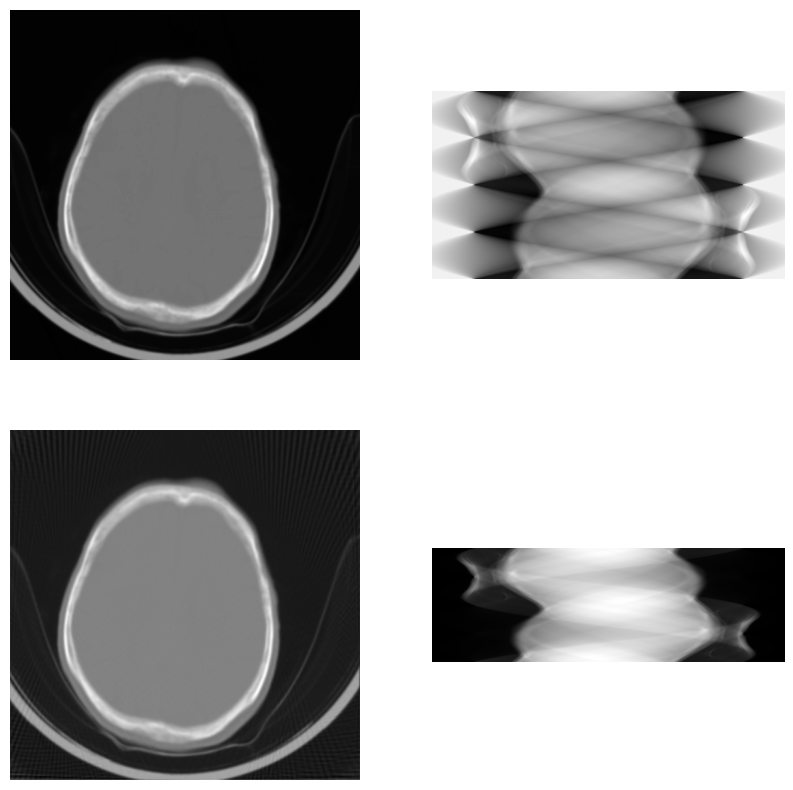

In [22]:
fig, axeses = plt.subplots(nrows=2, ncols=2)
fig.set_size_inches(10, 10)
axeses[0, 0].imshow(image, cmap='gray')
axeses[0, 1].imshow(sinogram, cmap='gray')

axeses[1, 0].imshow(recon2, cmap='gray')
axeses[1, 1].imshow(sinogram2, cmap='gray')

axeses = np.reshape(axeses, (-1,))
for kk in range(len(axeses)):
    axeses[kk].set_axesis_off()
